STEP-1 GPU AND MOUNTING DRIVE

In [1]:
# Check GPU is enabled
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️  No GPU detected! Go to Runtime → Change runtime type → select a GPU, then re-run this cell.")


CUDA available: True
GPU: Tesla T4


In [2]:
# Mount Google Drive (for persistent checkpoint storage)
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/d_linknet_road"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/checkpoints", exist_ok=True)
print(f"Project directory ready: {PROJECT_DIR}")

Mounted at /content/drive
Project directory ready: /content/drive/MyDrive/d_linknet_road


STEP-2

In [3]:
!pip install -q albumentations==1.4.18 opencv-python-headless tqdm pyyaml
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 17.7 MB/s eta 0:00:00
Dependencies installed.


STEP-3 UPLOADING DATA

In [5]:
import os
import zipfile

# Adjust this path to match exactly where you see the file in the Files panel
zip_path = "/content/dataset.zip"

assert os.path.exists(zip_path), f"File not found at {zip_path} — check the exact path in the Files panel (right-click the file → Copy path)"

EXTRACT_DIR = "/content/raw_dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(EXTRACT_DIR)

print(f"Extracted to: {EXTRACT_DIR}")

Extracted to: /content/raw_dataset


In [6]:
# Auto-detect the images/ and masks/ folders (handles nested zip structures)
from pathlib import Path

def find_data_dirs(root):
    root = Path(root)
    images_dir, masks_dir = None, None
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() == "images" and images_dir is None:
            images_dir = p
        if p.is_dir() and p.name.lower() == "masks" and masks_dir is None:
            masks_dir = p
    return images_dir, masks_dir

IMAGES_DIR, MASKS_DIR = find_data_dirs(EXTRACT_DIR)

if IMAGES_DIR is None or MASKS_DIR is None:
    print("Could not auto-detect images/ and masks/ folders. Folder structure found:")
    for p in Path(EXTRACT_DIR).rglob("*"):
        if p.is_dir():
            print(" ", p)
else:
    n_images = len(list(IMAGES_DIR.glob("*")))
    n_masks  = len(list(MASKS_DIR.glob("*")))
    print(f"✓ Found images dir: {IMAGES_DIR}  ({n_images} files)")
    print(f"✓ Found masks dir:  {MASKS_DIR}  ({n_masks} files)")
    if n_images != n_masks:
        print(f"⚠️  WARNING: image count ({n_images}) != mask count ({n_masks}). Check filenames match.")


✓ Found images dir: /content/raw_dataset/images  (70 files)
✓ Found masks dir:  /content/raw_dataset/masks  (70 files)


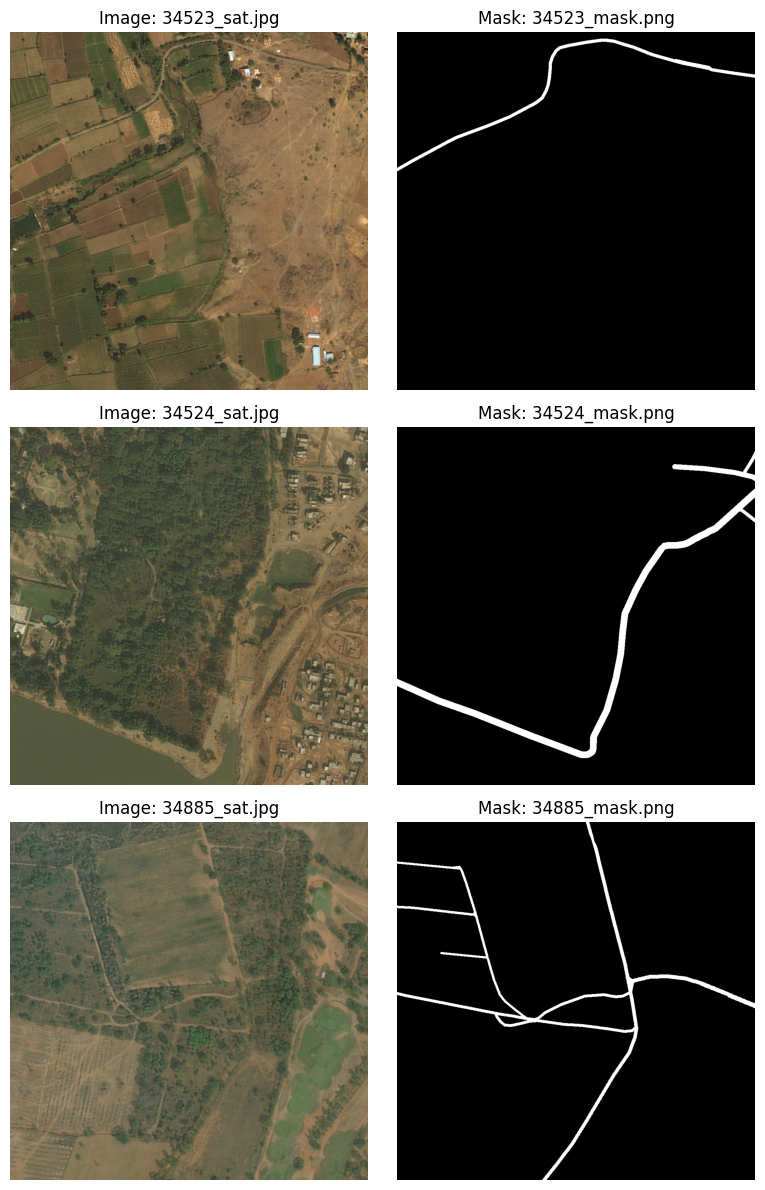

If image/mask pairs above look correctly aligned, proceed to the next step.


In [7]:
# Visual sanity check — view a few image/mask pairs before training
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Define common image extensions to search for masks
image_extensions = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}

sample_images = sorted(IMAGES_DIR.glob("*"))[:3]

fig, axes = plt.subplots(len(sample_images), 2, figsize=(8, 4 * len(sample_images)))
for i, img_path in enumerate(sample_images):
    # original img_path.name: e.g., '34523_sat.jpg'
    # original img_path.stem: e.g., '34523_sat'

    # Extract the base ID (e.g., '34523') by removing '_sat' suffix
    base_id = img_path.stem.replace('_sat', '')

    # Construct the expected mask stem (e.g., '34523_mask')
    expected_mask_stem = f"{base_id}_mask"

    mask_path = None
    # Search for this mask stem with various extensions in MASKS_DIR
    for ext in image_extensions:
        candidate_mask_path = MASKS_DIR / (expected_mask_stem + ext)
        if candidate_mask_path.exists():
            mask_path = candidate_mask_path
            break

    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Image: {img_path.name}")
    axes[i, 0].axis("off")

    if mask_path and mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(f"Mask: {mask_path.name}")
    else:
        axes[i, 1].set_title("⚠️ No matching mask found!")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()
print("If image/mask pairs above look correctly aligned, proceed to the next step.")

STEP-4 BUILD FILES

In [8]:
import os
os.makedirs('/content/d_linknet_road/models', exist_ok=True)
os.makedirs('/content/d_linknet_road/utils', exist_ok=True)
os.makedirs('/content/d_linknet_road/scripts', exist_ok=True)
os.makedirs('/content/d_linknet_road/configs', exist_ok=True)

In [9]:
%%writefile /content/d_linknet_road/models/d_linknet.py

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models


# ─────────────────────────────────────────────
# Building blocks
# ─────────────────────────────────────────────

class ConvBnRelu(nn.Module):
    """Conv → BN → ReLU"""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride,
                      padding=padding if dilation == 1 else dilation,
                      dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DilatedCenterBlock(nn.Module):
    """
    Center block with cascaded dilated convolutions.
    Dilation rates [1, 2, 4, 8] give receptive fields that
    'see through' tree canopy gaps to infer hidden road structure.
    """
    def __init__(self, channels=512):
        super().__init__()
        self.d1 = ConvBnRelu(channels, channels, dilation=1)
        self.d2 = ConvBnRelu(channels, channels, dilation=2)
        self.d4 = ConvBnRelu(channels, channels, dilation=4)
        self.d8 = ConvBnRelu(channels, channels, dilation=8)
        self.fuse = ConvBnRelu(channels * 4, channels, kernel=1, padding=0)

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(x)
        d4 = self.d4(x)
        d8 = self.d8(x)
        out = torch.cat([d1, d2, d4, d8], dim=1)
        return self.fuse(out)


class DecoderBlock(nn.Module):
    """
    LinkNet decoder block:
    1×1 conv (reduce channels) → transposed conv (upsample 2×) → 1×1 conv (restore channels)
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid_ch = in_ch // 4
        self.block = nn.Sequential(
            ConvBnRelu(in_ch, mid_ch, kernel=1, padding=0),
            nn.ConvTranspose2d(mid_ch, mid_ch, kernel_size=4, stride=2,
                               padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            ConvBnRelu(mid_ch, out_ch, kernel=1, padding=0),
        )

    def forward(self, x):
        return self.block(x)


# ─────────────────────────────────────────────
# Main D-LinkNet model
# ─────────────────────────────────────────────

class DLinkNet(nn.Module):
    """
    D-LinkNet with ResNet50 backbone.

    Encoder channels (ResNet50 layer outputs):
        layer1 → 256, layer2 → 512, layer3 → 1024, layer4 → 2048

    The dilated center block operates at the bottleneck (2048 ch),
    giving the network a large effective receptive field to handle
    roads hidden under vegetation.

    Args:
        num_classes  : 1 for binary road/no-road mask
        pretrained   : use ImageNet weights for ResNet50 encoder
    """

    def __init__(self, num_classes: int = 1, pretrained: bool = True):
        super().__init__()

        # ── Encoder (ResNet50 backbone) ──────────────────────────────
        backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        )

        self.firstconv  = backbone.conv1       # 3 → 64, stride 2
        self.firstbn    = backbone.bn1
        self.firstrelu  = backbone.relu
        self.firstpool  = backbone.maxpool     # stride 2  →  ¼ size

        self.encoder1   = backbone.layer1      # 64  → 256,  same size
        self.encoder2   = backbone.layer2      # 256 → 512,  ½ size
        self.encoder3   = backbone.layer3      # 512 → 1024, ½ size
        self.encoder4   = backbone.layer4      # 1024→ 2048, ½ size

        # ── Dilated center block ─────────────────────────────────────
        self.center = DilatedCenterBlock(channels=2048)

        # ── Decoder (LinkNet style) ──────────────────────────────────
        self.decoder4   = DecoderBlock(2048, 1024)
        self.decoder3   = DecoderBlock(1024, 512)
        self.decoder2   = DecoderBlock(512,  256)
        self.decoder1   = DecoderBlock(256,  64)

        # ── Final up-sampling to input resolution ────────────────────
        self.finaldeconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.finalconv = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, kernel_size=1),
        )

    def forward(self, x):
        # ── Encoder ──────────────────────────────────────────────────
        x0 = self.firstrelu(self.firstbn(self.firstconv(x)))  # /2
        x0p = self.firstpool(x0)                              # /4

        e1 = self.encoder1(x0p)   # /4,  256 ch
        e2 = self.encoder2(e1)    # /8,  512 ch
        e3 = self.encoder3(e2)    # /16, 1024 ch
        e4 = self.encoder4(e3)    # /32, 2048 ch

        # ── Dilated center ───────────────────────────────────────────
        c = self.center(e4)       # /32, 2048 ch (large receptive field)

        # ── Decoder with skip connections ────────────────────────────
        d4 = self.decoder4(c)   + e3   # /16, 1024 ch
        d3 = self.decoder3(d4)  + e2   # /8,  512  ch
        d2 = self.decoder2(d3)  + e1   # /4,  256  ch
        d1 = self.decoder1(d2)  + x0   # /2,  64   ch

        # ── Final upsampling → original resolution ───────────────────
        out = self.finaldeconv(d1)     # /1,  32   ch
        out = self.finalconv(out)      # /1,  num_classes
        return out                     # raw logits (apply sigmoid externally)


# ─────────────────────────────────────────────
# Quick sanity check
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model = DLinkNet(num_classes=1, pretrained=False)
    model.eval()
    x = torch.randn(2, 3, 512, 512)
    with torch.no_grad():
        y = model(x)
    print(f"Input : {x.shape}")
    print(f"Output: {y.shape}")   # expect [2, 1, 512, 512]
    params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"Params: {params:.1f} M")


Writing /content/d_linknet_road/models/d_linknet.py


In [ ]:
%%writefile /content/d_linknet_road/models/losses.py
"""
Loss functions for occluded road segmentation.



import torch
import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    """
    Soft Dice Loss — robust to class imbalance.
    Roads occupy ~5-15% of satellite imagery pixels.
    
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        probs_flat   = probs.view(-1)
        targets_flat = targets.view(-1)

        intersection = (probs_flat * targets_flat).sum()
        dice = (2.0 * intersection + self.smooth) / (
            probs_flat.sum() + targets_flat.sum() + self.smooth
        )
        return 1.0 - dice


class FocalLoss(nn.Module):
 

    Args:
        alpha : weight for positive class (roads)
        gamma : focusing parameter (2.0 is standard)
    
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()


class CombinedLoss(nn.Module):
    """
    Weighted combination: BCE + Dice + Focal

    Tuning guide for tree-occluded roads:
      - Increase focal_w  → more attention on hard/hidden road pixels
      - Increase dice_w   → improve recall of thin roads
      - Decrease bce_w    → reduce background dominance

    Default weights from ablation studies on SpaceNet & DeepGlobe datasets.
    """
    def __init__(
        self,
        bce_w:   float = 0.3,
        dice_w:  float = 0.4,
        focal_w: float = 0.3,
        focal_alpha: float = 0.75,
        focal_gamma: float = 2.0,
    ):
        super().__init__()
        self.bce_w   = bce_w
        self.dice_w  = dice_w
        self.focal_w = focal_w

        self.bce   = nn.BCEWithLogitsLoss()
        self.dice  = DiceLoss()
        self.focal = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        targets = targets.float()
        l_bce   = self.bce(logits, targets)
        l_dice  = self.dice(logits, targets)
        l_focal = self.focal(logits, targets)

        total = (
            self.bce_w   * l_bce  +
            self.dice_w  * l_dice +
            self.focal_w * l_focal
        )
        return total, {"bce": l_bce.item(), "dice": l_dice.item(), "focal": l_focal.item()}


class ConnectivityAwareLoss(nn.Module):
    loss = combined_loss + 0.1 * connectivity_loss
    
    def __init__(self):
        super().__init__()
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
                                dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
                                dtype=torch.float32).view(1, 1, 3, 3)
        self.register_buffer('sobel_x', sobel_x)
        self.register_buffer('sobel_y', sobel_y)

    def _edge_map(self, mask):
        gx = F.conv2d(mask, self.sobel_x, padding=1)
        gy = F.conv2d(mask, self.sobel_y, padding=1)
        return torch.sqrt(gx ** 2 + gy ** 2 + 1e-6)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        pred_edges   = self._edge_map(probs)
        target_edges = self._edge_map(targets.float())
        return F.mse_loss(pred_edges, target_edges)


Writing /content/d_linknet_road/models/losses.py


In [ ]:
%%writefile /content/d_linknet_road/utils/dataset.py
"""
Dataset & augmentation pipeline for satellite road extraction.
 
"""

import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path


# ─────────────────────────────────────────────
# Custom augmentations for canopy occlusion
# ─────────────────────────────────────────────

class ShadowSimulation(A.ImageOnlyTransform):
    """
    Randomly draws polygonal shadow patches on the image.
    Simulates tree canopy shadows falling on roads.
    p controls how often this is applied per image.
    """
    def __init__(self, shadow_intensity=(0.3, 0.7), num_shadows=(1, 4), p=0.5):
        super().__init__(p=p)
        self.shadow_intensity = shadow_intensity
        self.num_shadows = num_shadows

    def apply(self, img, **params):
        h, w = img.shape[:2]
        n = np.random.randint(*self.num_shadows)
        out = img.copy().astype(np.float32)
        for _ in range(n):
            intensity = np.random.uniform(*self.shadow_intensity)
            pts = np.random.randint([0, 0], [w, h], size=(np.random.randint(3, 7), 2))
            mask = np.zeros((h, w), dtype=np.float32)
            cv2.fillPoly(mask, [pts], 1.0)
            out[..., :3] *= (1 - intensity * mask[..., None])
        return out.clip(0, 255).astype(np.uint8)

    def get_transform_init_args_names(self):
        return ("shadow_intensity", "num_shadows")


class VegetationColorShift(A.ImageOnlyTransform):
    """
    Shifts hue toward green to simulate dense canopy colour spill
    onto adjacent road pixels — a common cause of false negatives.
    """
    def __init__(self, hue_shift=(-15, 15), sat_shift=(-20, 20), p=0.4):
        super().__init__(p=p)
        self.hue_shift = hue_shift
        self.sat_shift = sat_shift

    def apply(self, img, **params):
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.int32)
        hsv[..., 0] = np.clip(hsv[..., 0] + np.random.randint(*self.hue_shift), 0, 179)
        hsv[..., 1] = np.clip(hsv[..., 1] + np.random.randint(*self.sat_shift), 0, 255)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    def get_transform_init_args_names(self):
        return ("hue_shift", "sat_shift")


# ─────────────────────────────────────────────
# Augmentation pipelines
# ─────────────────────────────────────────────

def get_train_transforms(image_size: int = 512):
    return A.Compose([
        # Geometric
        A.RandomResizedCrop(height=image_size, width=image_size,
                            scale=(0.6, 1.0), ratio=(0.75, 1.33), p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2,
                           rotate_limit=45, p=0.5,
                           border_mode=cv2.BORDER_REFLECT),

        # Canopy-specific augmentations
        ShadowSimulation(shadow_intensity=(0.3, 0.7), num_shadows=(1, 5), p=0.6),
        VegetationColorShift(p=0.4),

        # Spectral / sensor variance
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30,
                             val_shift_limit=20, p=0.4),

        # Blur & noise (simulate haze, compression, lower res sensors)
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 7)),
            A.MotionBlur(blur_limit=7),
            A.MedianBlur(blur_limit=5),
        ], p=0.3),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.ISONoise(p=0.2),

        # CutOut — forces context-based inference (critical for hidden roads)
        A.CoarseDropout(max_holes=8, max_height=image_size // 8,
                        max_width=image_size // 8,
                        min_holes=1, fill_value=0, p=0.4),

        # Elastic / grid distortion — handles warped satellite projections
        A.OneOf([
            A.ElasticTransform(alpha=120, sigma=6, p=1.0),
            A.GridDistortion(p=1.0),
        ], p=0.2),

        # Normalise to ImageNet stats (ResNet50 pretrained)
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


def get_val_transforms(image_size: int = 512):
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


# ─────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────

class RoadDataset(Dataset):
    

    EXTS = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}

    def __init__(
        self,
        image_dir: str,
        mask_dir: str,
        transform=None,
        image_size: int = 512,
    ):
        self.image_dir = Path(image_dir)
        self.mask_dir  = Path(mask_dir)
        self.transform = transform or get_val_transforms(image_size)

        self.image_paths = sorted(
            p for p in self.image_dir.iterdir()
            if p.suffix.lower() in self.EXTS
        )
        if not self.image_paths:
            raise FileNotFoundError(f"No images found in {image_dir}")

    def __len__(self):
        return len(self.image_paths)

    def _find_mask(self, img_path: Path) -> Path:
        """Find matching mask by stem, trying multiple extensions."""
        for ext in [".png", ".tif", ".tiff", ".jpg"]:
            candidate = self.mask_dir / (img_path.stem + ext)
            if candidate.exists():
                return candidate
        raise FileNotFoundError(
            f"No mask found for {img_path.name} in {self.mask_dir}"
        )

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        mask_path = self._find_mask(img_path)

        # Load image (force 3-channel RGB)
        image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load mask (binary: road=1, background=0)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.uint8)   # normalise to 0/1

        augmented = self.transform(image=image, mask=mask)
        image = augmented["image"]              # float tensor [3, H, W]
        mask  = augmented["mask"].unsqueeze(0)  # float tensor [1, H, W]

        return image, mask.float(), str(img_path.name)


# ─────────────────────────────────────────────
# DataLoader factory
# ─────────────────────────────────────────────

def get_dataloaders(
    train_img_dir: str,
    train_mask_dir: str,
    val_img_dir: str,
    val_mask_dir: str,
    image_size: int = 512,
    batch_size: int = 8,
    num_workers: int = 4,
):
    train_ds = RoadDataset(train_img_dir, train_mask_dir,
                           transform=get_train_transforms(image_size))
    val_ds   = RoadDataset(val_img_dir,   val_mask_dir,
                           transform=get_val_transforms(image_size))

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )
    print(f"Train: {len(train_ds)} images | Val: {len(val_ds)} images")
    return train_loader, val_loader


Writing /content/d_linknet_road/utils/dataset.py


In [ ]:
%%writefile /content/d_linknet_road/utils/metrics.py

import torch
import numpy as np
import cv2
from scipy import ndimage


# ─────────────────────────────────────────────
# Pixel-level metrics (fast, GPU-compatible)
# ─────────────────────────────────────────────

class RoadMetrics:
    def __init__(self, threshold: float = 0.5):
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0.0

    def update(self, logits: torch.Tensor, targets: torch.Tensor):
        preds = (torch.sigmoid(logits) > self.threshold).float()
        targets = targets.float()

        self.tp += (preds * targets).sum().item()
        self.fp += (preds * (1 - targets)).sum().item()
        self.fn += ((1 - preds) * targets).sum().item()
        self.tn += ((1 - preds) * (1 - targets)).sum().item()

    @property
    def precision(self) -> float:
        return self.tp / (self.tp + self.fp + 1e-8)

    @property
    def recall(self) -> float:
        """High recall = fewer missed roads under trees."""
        return self.tp / (self.tp + self.fn + 1e-8)

    @property
    def f1(self) -> float:
        p, r = self.precision, self.recall
        return 2 * p * r / (p + r + 1e-8)

    @property
    def iou(self) -> float:
        return self.tp / (self.tp + self.fp + self.fn + 1e-8)

    @property
    def accuracy(self) -> float:
        total = self.tp + self.fp + self.fn + self.tn
        return (self.tp + self.tn) / (total + 1e-8)

    def compute(self) -> dict:
        return {
            "iou":       round(self.iou,       4),
            "f1":        round(self.f1,        4),
            "precision": round(self.precision, 4),
            "recall":    round(self.recall,    4),
            "accuracy":  round(self.accuracy,  4),
        }


# ─────────────────────────────────────────────
# Connectivity / topology metrics (CPU, per-batch)
# ─────────────────────────────────────────────

def compute_connectivity_score(pred_mask: np.ndarray,
                                gt_mask: np.ndarray,
                                min_component: int = 50) -> float:
    
    labeled_gt, n_components = ndimage.label(gt_mask)
    if n_components == 0:
        return 1.0   # no roads → nothing to evaluate

    connected = 0
    total = 0

    for comp_id in range(1, n_components + 1):
        comp_mask = (labeled_gt == comp_id)
        if comp_mask.sum() < min_component:
            continue   # skip tiny fragments

        # Find the pred pixels that overlap this GT component
        pred_in_comp = pred_mask * comp_mask
        if pred_in_comp.sum() == 0:
            total += 1
            continue

        # Check if the pred pixels form a single connected component
        labeled_pred, n_pred_comp = ndimage.label(pred_in_comp)
        if n_pred_comp == 1:
            connected += 1
        total += 1

    return connected / (total + 1e-8)


def road_apls_iou(pred_mask: np.ndarray,
                   gt_mask: np.ndarray,
                   buffer_px: int = 5) -> dict:
    """
    Buffered IoU: dilates ground-truth roads by buffer_px before IoU.
    Accounts for annotation imprecision and slight spatial offsets
    caused by projection corrections in satellite imagery.
    """
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (buffer_px * 2 + 1, buffer_px * 2 + 1)
    )
    gt_dilated = cv2.dilate(gt_mask.astype(np.uint8), kernel)

    intersection = np.logical_and(pred_mask, gt_dilated).sum()
    union        = np.logical_or(pred_mask,  gt_dilated).sum()
    buffered_iou = intersection / (union + 1e-8)

    connectivity = compute_connectivity_score(pred_mask, gt_mask)

    return {
        "buffered_iou":    round(float(buffered_iou),    4),
        "connectivity":    round(float(connectivity),    4),
        "road_quality":    round(float((buffered_iou + connectivity) / 2), 4),
    }


# ─────────────────────────────────────────────
# Threshold search utility
# ─────────────────────────────────────────────

def find_best_threshold(logits_list: list, masks_list: list,
                         thresholds=None) -> dict:
    """
    Sweeps probability thresholds and returns the one that maximises F1.
    Run once on validation set after training to tune the decision boundary.
    """
    if thresholds is None:
        thresholds = np.arange(0.3, 0.75, 0.05)

    best_t, best_f1 = 0.5, 0.0
    results = []

    for t in thresholds:
        m = RoadMetrics(threshold=t)
        for logits, targets in zip(logits_list, masks_list):
            m.update(logits, targets)
        stats = m.compute()
        results.append({"threshold": round(t, 2), **stats})
        if stats["f1"] > best_f1:
            best_f1, best_t = stats["f1"], t

    return {"best_threshold": best_t, "best_f1": best_f1, "sweep": results}


Writing /content/d_linknet_road/utils/metrics.py


STEP-5 split data into train/val



In [13]:
import shutil, random
from pathlib import Path

random.seed(42)

PROCESSED_DIR = Path("/content/processed_data")
for split in ["train", "val"]:
    (PROCESSED_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (PROCESSED_DIR / split / "masks").mkdir(parents=True, exist_ok=True)

# Pair up images with masks (by matching stem, any extension)
# Correct: Create mask_lookup keys to match image stems (e.g., '34523_sat' from '34523_mask')
mask_lookup = {p.stem.replace('_mask', '_sat'): p for p in MASKS_DIR.iterdir() if p.is_file()}
all_images = [p for p in IMAGES_DIR.iterdir() if p.is_file()]
pairs = [(img, mask_lookup[img.stem]) for img in all_images if img.stem in mask_lookup]

print(f"Matched pairs: {len(pairs)} / {len(all_images)} images")
if len(pairs) < len(all_images):
    missing = [img.name for img in all_images if img.stem not in mask_lookup]
    print(f"⚠️  {len(missing)} images have no matching mask, e.g.: {missing[:5]}")

random.shuffle(pairs)
val_ratio = 0.15
n_val = max(1, int(len(pairs) * val_ratio))
val_pairs   = pairs[:n_val]
train_pairs = pairs[n_val:]

def copy_pairs(pair_list, split_name):
    for img_path, mask_path in pair_list:
        shutil.copy(img_path, PROCESSED_DIR / split_name / "images" / img_path.name)
        # save mask with same stem as image, .png extension for consistency
        dst_mask = PROCESSED_DIR / split_name / "masks" / (img_path.stem + ".png")
        if mask_path.suffix.lower() == ".png":
            shutil.copy(mask_path, dst_mask)
        else:
            # Using cv2.imread for non-PNG masks (e.g., .tif) to convert them to PNG
            img_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            cv2.imwrite(str(dst_mask), img_mask)

copy_pairs(train_pairs, "train")
copy_pairs(val_pairs, "val")

print(f"\nTrain: {len(train_pairs)} pairs")
print(f"Val:   {len(val_pairs)} pairs")

# Verify files are actually present after copying
num_train_images_verified = len(list((PROCESSED_DIR / "train" / "images").iterdir()))
num_val_images_verified = len(list((PROCESSED_DIR / "val" / "images").iterdir()))
print(f"Verified: {num_train_images_verified} train images and {num_val_images_verified} val images copied to {PROCESSED_DIR}")

print(f"Data ready at: {PROCESSED_DIR}")

Matched pairs: 70 / 70 images

Train: 60 pairs
Val:   10 pairs
Verified: 60 train images and 10 val images copied to /content/processed_data
Data ready at: /content/processed_data


STEP-6 configure training


In [14]:
# ─── Training Configuration ───────────────────────────────────────
IMAGE_SIZE   = 512      # must be divisible by 32; reduce to 384 if OOM
BATCH_SIZE   = 8        # reduce to 4 if you hit GPU OOM errors
EPOCHS       = 60       # increase for better results if you have time/data
ENCODER_LR   = 1e-4     # learning rate for pretrained ResNet50 backbone
DECODER_LR   = 1e-3     # learning rate for new decoder layers
NUM_WORKERS  = 2        # Colab default; raise to 4 on Colab Pro

CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"   # saved to Google Drive
print("Configuration set.")
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")


Configuration set.
Checkpoints will be saved to: /content/drive/MyDrive/d_linknet_road/checkpoints


STEP-7 TRAIN THE MODEL

In [15]:
import sys
sys.path.insert(0, "/content/d_linknet_road")

import time
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast

from models.d_linknet import DLinkNet
from models.losses import CombinedLoss
from utils.dataset import get_dataloaders
from utils.metrics import RoadMetrics

RESUME = False   # set True to continue training from the last checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

train_loader, val_loader = get_dataloaders(
    train_img_dir  = str(PROCESSED_DIR / "train" / "images"),
    train_mask_dir = str(PROCESSED_DIR / "train" / "masks"),
    val_img_dir    = str(PROCESSED_DIR / "val" / "images"),
    val_mask_dir   = str(PROCESSED_DIR / "val" / "masks"),
    image_size  = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
)


Training on: cuda
Train: 60 images | Val: 10 images


/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [16]:
model = DLinkNet(num_classes=1, pretrained=True).to(device)

encoder_params = (list(model.firstconv.parameters()) + list(model.encoder1.parameters()) +
                   list(model.encoder2.parameters()) + list(model.encoder3.parameters()) +
                   list(model.encoder4.parameters()))
decoder_params = [p for p in model.parameters() if not any(p is ep for ep in encoder_params)]

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": ENCODER_LR},
    {"params": decoder_params, "lr": DECODER_LR},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=max(1, EPOCHS // 3))
criterion = CombinedLoss(bce_w=0.3, dice_w=0.4, focal_w=0.3)
scaler = GradScaler()

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
ckpt_path = f"{CHECKPOINT_DIR}/best_model.pth"

start_epoch, best_iou = 0, 0.0
if RESUME and os.path.exists(ckpt_path):
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state["model"])
    start_epoch = state["epoch"] + 1
    best_iou = state["best_iou"]
    print(f"Resumed from epoch {start_epoch}, best IoU so far: {best_iou:.4f}")
else:
    print("Starting fresh training run.")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 139MB/s]


Starting fresh training run.


/tmp/ipykernel_1065/1970366114.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [17]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    metrics = RoadMetrics()
    total_loss = 0.0
    for images, masks, _ in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        with autocast():
            logits = model(images)
            loss, parts = criterion(logits, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        metrics.update(logits.detach(), masks.detach())
    return total_loss / len(loader), metrics.compute()

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    metrics = RoadMetrics()
    total_loss = 0.0
    for images, masks, _ in loader:
        images, masks = images.to(device), masks.to(device)
        with autocast():
            logits = model(images)
            loss, _ = criterion(logits, masks)
        total_loss += loss.item()
        metrics.update(logits, masks)
    return total_loss / len(loader), metrics.compute()

print("Training functions ready.")


Training functions ready.


In [18]:
history = {"train_iou": [], "val_iou": [], "train_loss": [], "val_loss": []}
patience, no_improve = 15, 0

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()
    train_loss, train_stats = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    val_loss, val_stats = validate(model, val_loader, criterion, device)
    scheduler.step()
    elapsed = time.time() - t0

    history["train_iou"].append(train_stats["iou"])
    history["val_iou"].append(val_stats["iou"])
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} ({elapsed:.0f}s) | "
          f"Train: loss={train_loss:.4f} IoU={train_stats['iou']:.4f} Recall={train_stats['recall']:.4f} | "
          f"Val: loss={val_loss:.4f} IoU={val_stats['iou']:.4f} Recall={val_stats['recall']:.4f}")

    if val_stats["iou"] > best_iou:
        best_iou = val_stats["iou"]
        no_improve = 0
        torch.save({
            "epoch": epoch, "model": model.state_dict(),
            "optimizer": optimizer.state_dict(), "best_iou": best_iou,
            "val_stats": val_stats,
        }, ckpt_path)
        print(f"   ✓ New best IoU={best_iou:.4f} — saved to Google Drive")
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\nEarly stopping: no improvement for {patience} epochs.")
        break

print(f"\n{'='*60}\nTraining complete. Best Val IoU: {best_iou:.4f}")
print(f"Best model saved at: {ckpt_path}")


/tmp/ipykernel_1065/2093357372.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1065/2093357372.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch   1/60 (8s) | Train: loss=0.5754 IoU=0.0436 Recall=0.2639 | Val: loss=0.6932 IoU=0.0509 Recall=0.9438
   ✓ New best IoU=0.0509 — saved to Google Drive
Epoch   2/60 (5s) | Train: loss=0.5227 IoU=0.0138 Recall=0.0179 | Val: loss=0.6254 IoU=0.0465 Recall=0.5426
Epoch   3/60 (6s) | Train: loss=0.5056 IoU=0.0032 Recall=0.0035 | Val: loss=0.5070 IoU=0.0129 Recall=0.0168
Epoch   4/60 (5s) | Train: loss=0.4972 IoU=0.0044 Recall=0.0045 | Val: loss=0.4930 IoU=0.0138 Recall=0.0169
Epoch   5/60 (5s) | Train: loss=0.4893 IoU=0.0034 Recall=0.0035 | Val: loss=0.4771 IoU=0.0019 Recall=0.0020
Epoch   6/60 (7s) | Train: loss=0.4814 IoU=0.0086 Recall=0.0088 | Val: loss=0.4730 IoU=0.0008 Recall=0.0008
Epoch   7/60 (5s) | Train: loss=0.4657 IoU=0.1839 Recall=0.2882 | Val: loss=0.4647 IoU=0.0107 Recall=0.0164
Epoch   8/60 (5s) | Train: loss=0.4590 IoU=0.2298 Recall=0.3980 | Val: loss=0.4213 IoU=0.3066 Recall=0.3857
   ✓ New best IoU=0.3066 — saved to Google Drive
Epoch   9/60 (5s) | Train: loss=0.4504

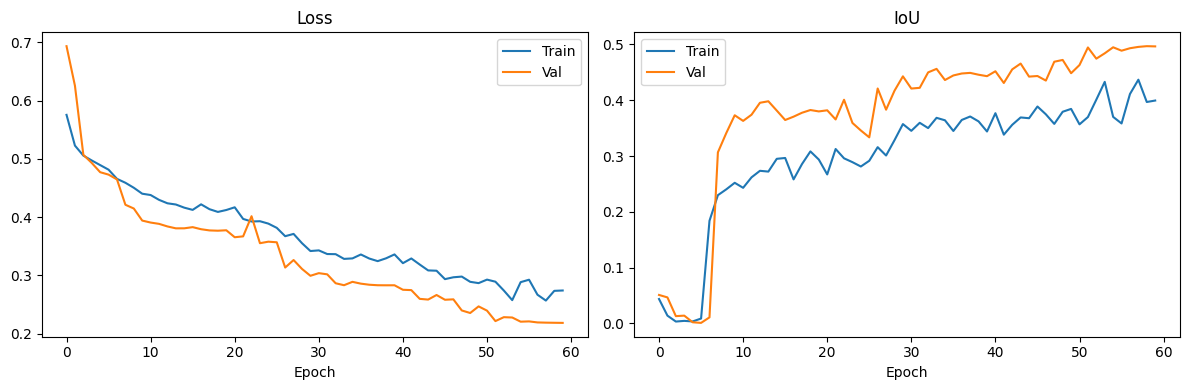

In [19]:


    # Plot training curves
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(history["train_iou"], label="Train")
    axes[1].plot(history["val_iou"], label="Val")
    axes[1].set_title("IoU"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout()
    plt.show()

STEP-8 VISUALS

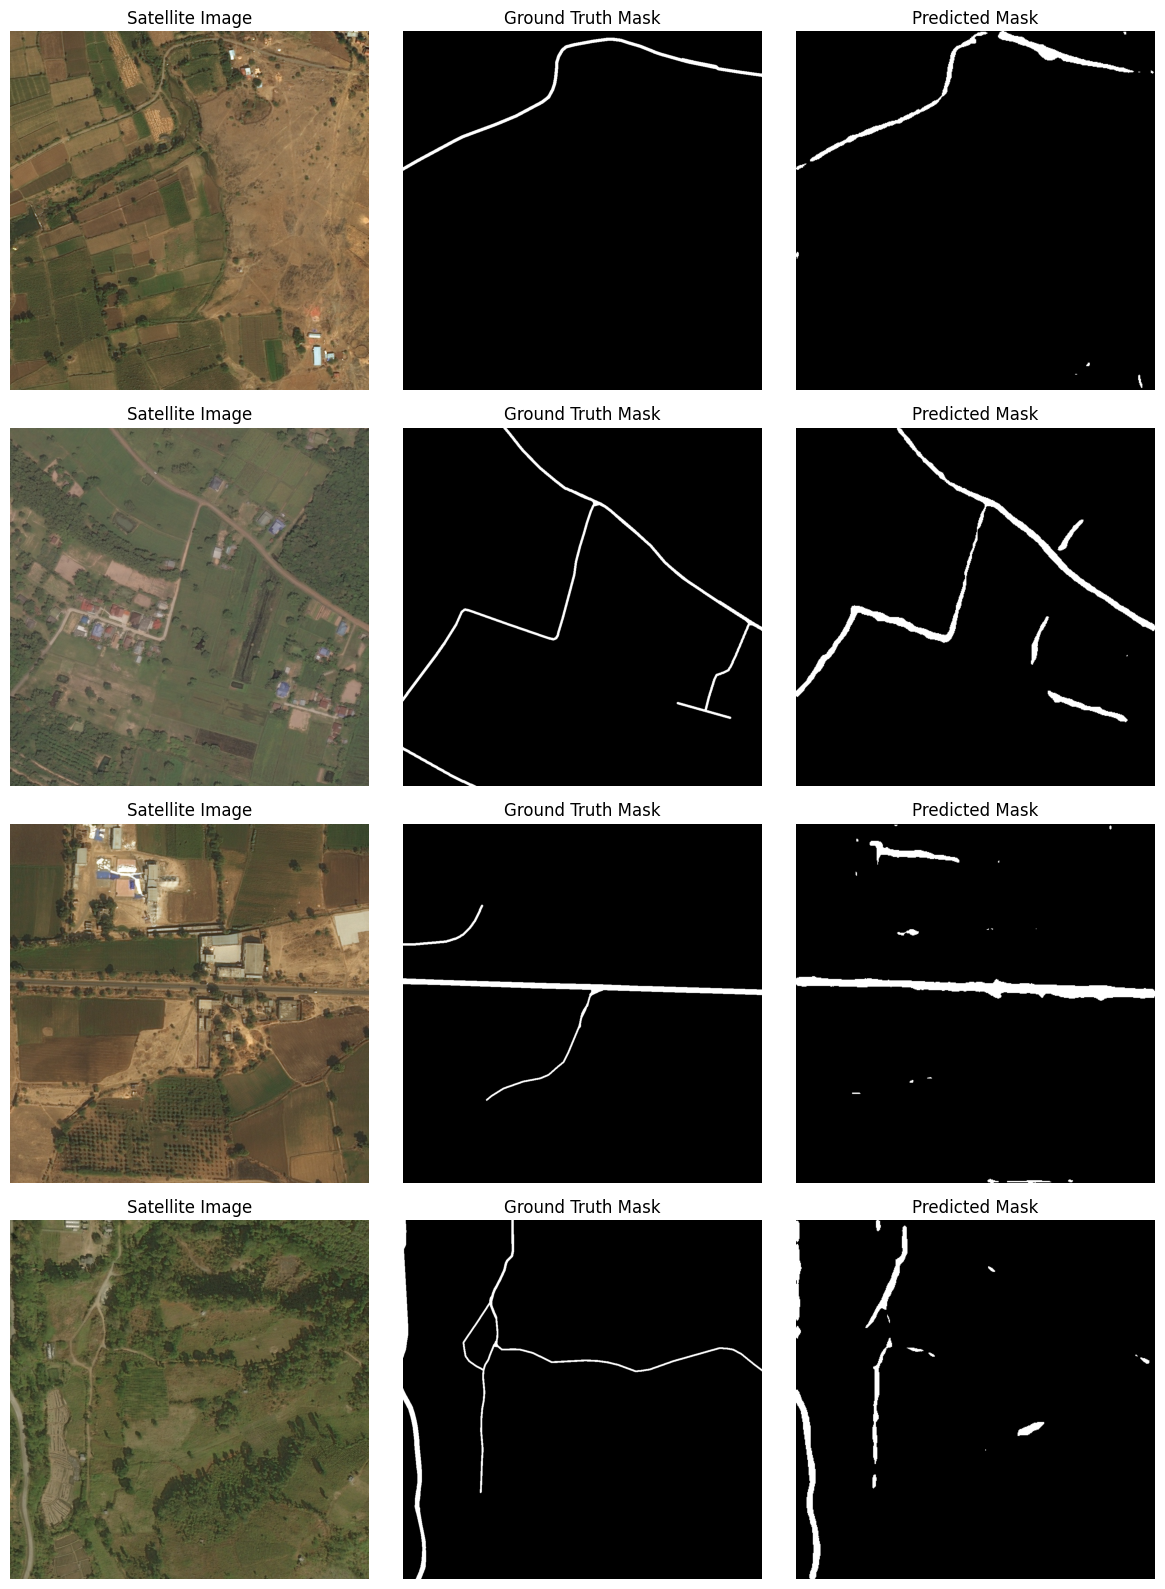

In [35]:
import torch.nn.functional as F

@torch.no_grad()
def predict_mask(model, image_rgb, device, size=IMAGE_SIZE, threshold=0.5):
    h, w = image_rgb.shape[:2]
    img = cv2.resize(image_rgb, (size, size)).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
    img = (img - mean) / std
    tensor = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
    logit = model(tensor)
    prob = torch.sigmoid(logit).squeeze().cpu().numpy()
    mask = (prob > threshold).astype(np.uint8) * 255
    return cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

model.eval()
val_images = sorted((PROCESSED_DIR / "val" / "images").glob("*"))[:4]

fig, axes = plt.subplots(len(val_images), 3, figsize=(12, 4 * len(val_images)))
for i, img_path in enumerate(val_images):
    image = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    gt_mask_path = PROCESSED_DIR / "val" / "masks" / (img_path.stem + ".png")
    gt_mask = cv2.imread(str(gt_mask_path), cv2.IMREAD_GRAYSCALE)

    pred_mask = predict_mask(model, image, device)

    axes[i, 0].imshow(image); axes[i, 0].set_title("Satellite Image"); axes[i, 0].axis("off")
    axes[i, 1].imshow(gt_mask, cmap="gray"); axes[i, 1].set_title("Ground Truth Mask"); axes[i, 1].axis("off")
    axes[i, 2].imshow(pred_mask, cmap="gray"); axes[i, 2].set_title("Predicted Mask"); axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


In [21]:
# Test-Time Augmentation: averages 6 orientations for more robust predictions
TTA_OPS = [
    (lambda x: x,                          lambda x: x),
    (lambda x: torch.flip(x, dims=[3]),    lambda x: torch.flip(x, dims=[3])),
    (lambda x: torch.flip(x, dims=[2]),    lambda x: torch.flip(x, dims=[2])),
    (lambda x: torch.rot90(x, 1, [2,3]),   lambda x: torch.rot90(x, -1, [2,3])),
    (lambda x: torch.rot90(x, 2, [2,3]),   lambda x: torch.rot90(x,  2, [2,3])),
    (lambda x: torch.rot90(x, 3, [2,3]),   lambda x: torch.rot90(x, -3, [2,3])),
]

@torch.no_grad()
def predict_with_tta(model, image_rgb, device, size=IMAGE_SIZE, threshold=0.5):
    h, w = image_rgb.shape[:2]
    img = cv2.resize(image_rgb, (size, size)).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
    img = (img - mean) / std
    tensor = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).float().to(device)

    probs = []
    for aug, deaug in TTA_OPS:
        logit = model(aug(tensor))
        probs.append(torch.sigmoid(deaug(logit)))
    avg_prob = torch.stack(probs).mean(dim=0).squeeze().cpu().numpy()
    mask = (avg_prob > threshold).astype(np.uint8) * 255
    return cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

def clean_mask(mask, min_area=200, close_kernel=9):
    """Morphological closing fills small gaps caused by tree occlusion."""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_kernel, close_kernel))
    closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed)
    cleaned = np.zeros_like(closed)
    for i in range(1, n_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == i] = 255
    return cleaned

print("TTA + post-processing functions ready.")


TTA + post-processing functions ready.


STEP-9 running predictions

In [2]:
# Upload new satellite images to predict on (optional — skip if just evaluating on val set)
print("Upload one or more satellite images to generate road masks for...")
new_uploads = files.upload()

os.makedirs("/content/new_predictions", exist_ok=True)

for fname in new_uploads.keys():
    image = cv2.cvtColor(cv2.imread(fname), cv2.COLOR_BGR2RGB)
    mask = predict_with_tta(model, image, device)
    mask = clean_mask(mask)

    out_path = f"/content/new_predictions/{Path(fname).stem}_road_mask.png"
    cv2.imwrite(out_path, mask)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image); axes[0].set_title(fname); axes[0].axis("off")
    axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Predicted Road Mask"); axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Saved: {out_path}")


Upload one or more satellite images to generate road masks for...


NameError: name 'files' is not defined

In [ ]:
# Download all predicted masks as a zip
import shutil
shutil.make_archive("/content/predicted_masks", "zip", "/content/new_predictions")
files.download("/content/predicted_masks.zip")


STEP-10 FINALEEE


In [ ]:
#files.download(ckpt_path)
print(f"Downloaded: {ckpt_path}")
print(f"\nThis file is also permanently saved in your Google Drive at:\n{ckpt_path}")
print("\nTo reuse this model later, load it with:")
print("""
model = DLinkNet(num_classes=1, pretrained=False)
state = torch.load("best_model.pth", map_location=device)
model.load_state_dict(state["model"])
model.eval()
""")